In [80]:
# GLOBAL #
import random
import pandas as pd
from collections import defaultdict, Counter
import numpy as np
from itertools import product
from scipy.stats import truncnorm
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

random.seed(123)
np.random.seed(123)

In [81]:
# HELPER FUNCTIONS #

## From Markov Sampling ##

#create strings from the .csv file (for fish)
def readSequences(species_df, by_length=True):

        sequences = []

        grouped = species_df.groupby(
            ["trial_id", "sequence_id", "fish_id"]
        )

        for (_, _, fish_id), group in grouped:

            group = group.sort_values("order_id")
            parts = []

            for _, row in group.iterrows():

                if by_length:
                    parts.append(str(row["state"]) * int(row["length"]))
                else:
                    parts.append(str(row["state"]))

            sequences.append("".join(parts) + "")

        return sequences

# collapse sequence by self-transitions (e.g. [aaaabbbbcccdddccc] = [abcdc]) for collapsed context model
def collapseLength(seq):

    collapsed = []

    for s in seq:
        if not collapsed or collapsed[-1] != s:
            collapsed.append(s)

    return collapsed

# check if tuple has consecutive repeated states (we want to ignore these combinations in collapsed context model transition matrix)
def hasConsecutiveRepeats(states):

    for i in range(len(states) - 1):
        if states[i] == states[i + 1]:
            return True
        
    return False

# find indices of first state in each state run within sequence (e.g., [aaaabbbbcccdddccccc] = [0, 4, 8, 11, 14])
def uniqueIdxs(seq):

    lasts = []
    runChar = seq[0]

    for i, s in enumerate(seq[1:], start=1):
        if s != runChar:
            lasts.append(i - 1)
            runChar = s

    lasts.append(len(seq) - 1)
    return lasts

# expand  numeric vector into repetitions corresponding to each number value (e.g., [0, 4, 8, 11, 14] = [0, 0, 0, 0, 4, 4, 4, 4, 8, 8, 8, 11, 11, 11, 14, 14, 14]) 
# for matching strings to indices in collapsed context model 
def expandVec(vec):

    if not vec:
        return []
    
    result = []

    vecIDX = 0

    for pos in range(vec[-1] + 1):
        while vecIDX < len(vec) - 1 and pos > vec[vecIDX]:
            vecIDX += 1
        result.append(vec[vecIDX])

    return result

#### transition matrices ####

def collapsedTransNorm(states, lines, k, smoother):
    
    transitions = defaultdict(Counter)

    #for k=0 version, transition matrix turns into simple marginal state distributions
    if k == 0:
        for state in states:
            transitions[()][state] = smoother #add laplace smoother to each curr state

        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1 #add one count in corresponding transition cell for each instance of each state

        total = sum(transitions[()].values())

        return {(): {s: c / total for s, c in transitions[()].items()}} #normalize

    for prev in product(states, repeat=k):

        if hasConsecutiveRepeats(prev): #if prev tuple has consecutive repeats, skip (because this cannot be observed when self-transitions are collapsed)
            continue

        for curr in states:
            transitions[prev][curr] = smoother #add laplace smoother to every valid combination of prev & curr states

    for seq in lines:

        idxs = uniqueIdxs(seq) #find indices of unique states in sequence
        idxsExpanded = expandVec(idxs) #expand indices for mapping

        for t in range(1, len(seq)):

            idxsCollapsed = idxs.index(idxsExpanded[t - 1]) #find corresponding index of each token

            if idxsCollapsed < k - 1:
                continue

            prevIdxsUnique = idxs[idxsCollapsed- (k - 1):idxsCollapsed+ 1]
            prev = tuple(seq[i] for i in prevIdxsUnique)
            curr = seq[t]
            transitions[prev][curr] += 1

    transNorm = {}

    for cond, counter in transitions.items():
        total = sum(counter.values())
        transNorm[cond] = {s: c / total for s, c in counter.items()} #normalize 

    return transNorm

def collapsedTransCount(lines, k):

    transitions = defaultdict(Counter)

    # if k is zero, just count instances of each state
    if k == 0:
        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1

        return transitions
    
    for seq in lines:
        idxs = uniqueIdxs(seq)
        idxsExpanded = expandVec(idxs)

        for t in range(1, len(seq)):
            idxsCollapsed= idxs.index(idxsExpanded[t - 1])

            if idxsCollapsed< k - 1:
                continue

            prevIdxsUnique = idxs[idxsCollapsed- (k - 1):idxsCollapsed+ 1]
            prev = tuple(seq[i] for i in prevIdxsUnique)
            curr = seq[t]
            transitions[prev][curr] += 1

    return transitions

## Generation Functions ##

#initiate starting context based on count frequency
def sample_start_context(counts):

    contexts = list(counts.keys()) #all observed contexts from count transitions


    weights = np.array(
        [sum(nexts.values()) for nexts in counts.values()],
        dtype=float
    )

    #compute probs of each transition
    weights /= weights.sum()

    # select starting context according to its frequency
    idx = np.random.choice(len(contexts), p=weights)

    return contexts[idx]

# recover unique states from sequence
def collapsed_context(seq, k):

    if k == 0:
        return ()

    collapsed = collapseLength(seq)

    if len(collapsed) < k:
        return None

    return tuple(collapsed[-k:])

#sample next state from normalized matrix
def sample_next(trans, context):

    probs = trans[context]

    states = list(probs.keys())
    weights = list(probs.values())

    return np.random.choice(states, p=weights)

#generate sequence
def generate_sequence(trans, counts, k, length):

    start_context = sample_start_context(counts)

    seq = list(start_context)

    while len(seq) < length:

        context = collapsed_context(seq, k)

        if context not in trans:
            break

        probs = trans[context]

        states = list(probs.keys())
        weights = list(probs.values())

        next_state = np.random.choice(states, p=weights)

        seq.append(next_state)

    return ''.join(seq)


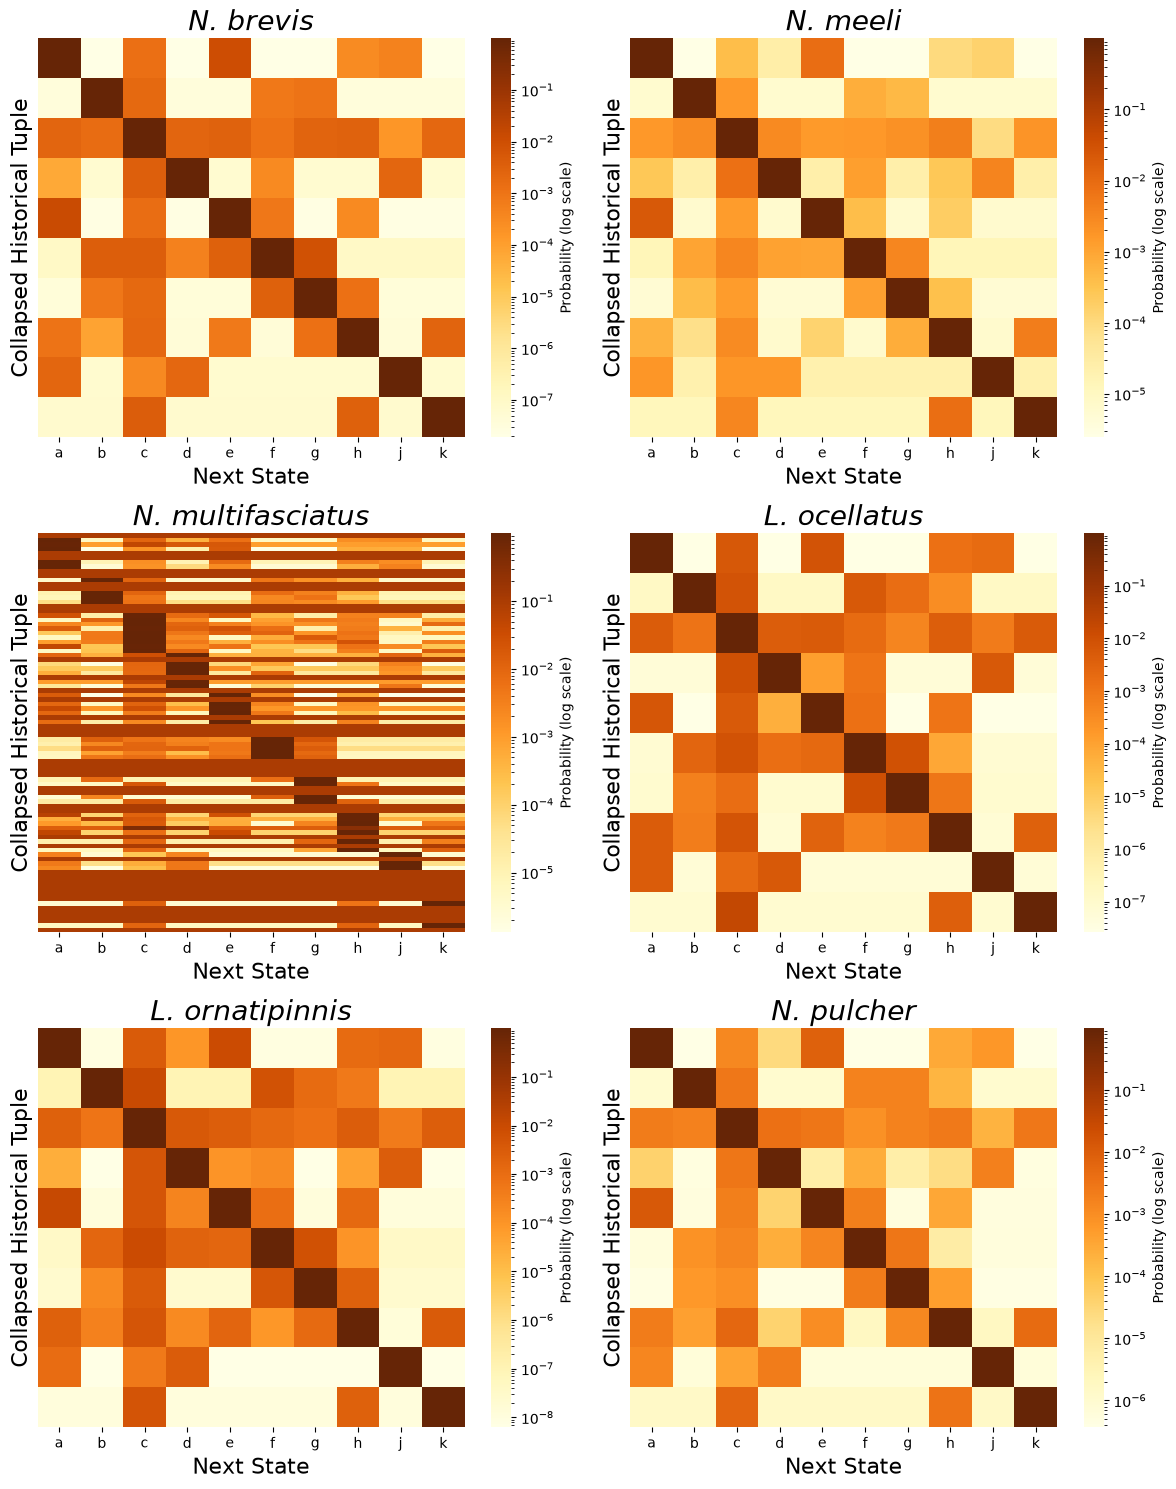

In [83]:
# FISH #

# user input -------

#note: "mil" is a typo for "mee" for "meeli"--I can't read apparently...
fishMap = {'bre': [1, .001, 700, 1670, 'N. brevis'], 'mil': [1, .1, 475, 1930, 'N. meeli'], 'mul': [2, .1, 640, 1440, 'N. multifasciatus'], 
           'oce': [1, .001, 400, 1470, 'L. ocellatus'], 'orn': [1, .001, 450, 1885, 'L. ornatipinnis'], 'pul': [1, .1, 723, 1828, 'N. pulcher']} 
# dict for species: [best k, best smoother, length q1, length q3, heatmap title], 
# extracted from 05-postprocessing results (k, smoother) and 01-preprocessing statsTable (q1, q3)

nLines = 200

# run generation --------------

dat = pd.read_csv("../fish-data/raw/PrettyDat.csv")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()
loc = 0

for species, speciesDF in dat.groupby("species"):

    ax = axes[loc]

    species = str(species)
    outFilename = f"{species}_playback.txt"

    #read all lines
    lines = readSequences(speciesDF)

    # set up length distribution to draw from truncated normal distribution between q1 and q3 of each corpus
    q1 = fishMap[species][2]
    q3 = fishMap[species][3]

    mu = (q1 + q3) / 2
    sigma = (q3 - q1) / (2 * 0.67448975)

    #beginning and end of truncated normal are not simply q1 and q3, but mean-centered and renormalized versions (see scipy.stats documentation)
    a, b = (q1 - mu)/sigma, (q3 - mu)/sigma 

    # find unique states
    states = sorted({char for line in lines for char in line})

    # k-order model
    trans = collapsedTransNorm(states = states, lines = lines, k = fishMap[species][0], smoother = fishMap[species][1]) 

    # k-order counts
    counts = collapsedTransCount(lines, fishMap[species][0])

    # write generated sequences
    with open(outFilename, "w") as f:

        for i in range(nLines):

            seqLen = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=1) #sample sequence length from truncated N dist

            out = generate_sequence(trans, counts, fishMap[species][0], seqLen)

            f.write(out + "\n")

    #make heatmap
    pMatrix = pd.DataFrame(trans).T.fillna(0)

    sorted_index = sorted(pMatrix.index, key=lambda x: x[-1]) #sort matrix rows by most recent character in history
    pMatrix = pMatrix.reindex(sorted_index)

    sb.heatmap(pMatrix,
    norm=mcolors.LogNorm(vmin=pMatrix.min().min(), vmax=pMatrix.max().max()),
    yticklabels=False,
    xticklabels=True,
    cmap="YlOrBr",
    cbar_kws={"label": "Probability (log scale)"},
    ax=ax
    )

    ax.set_xlabel("Next State", fontsize = 16)
    ax.set_ylabel("Collapsed Historical Tuple", fontsize = 16)
    ax.set_title(fishMap[species][4], fontsize = 20, style = 'italic')
    

    loc += 1

plt.tight_layout()
plt.savefig(f"../plots/fishHeatmap.png")
plt.show()
plt.close()
    


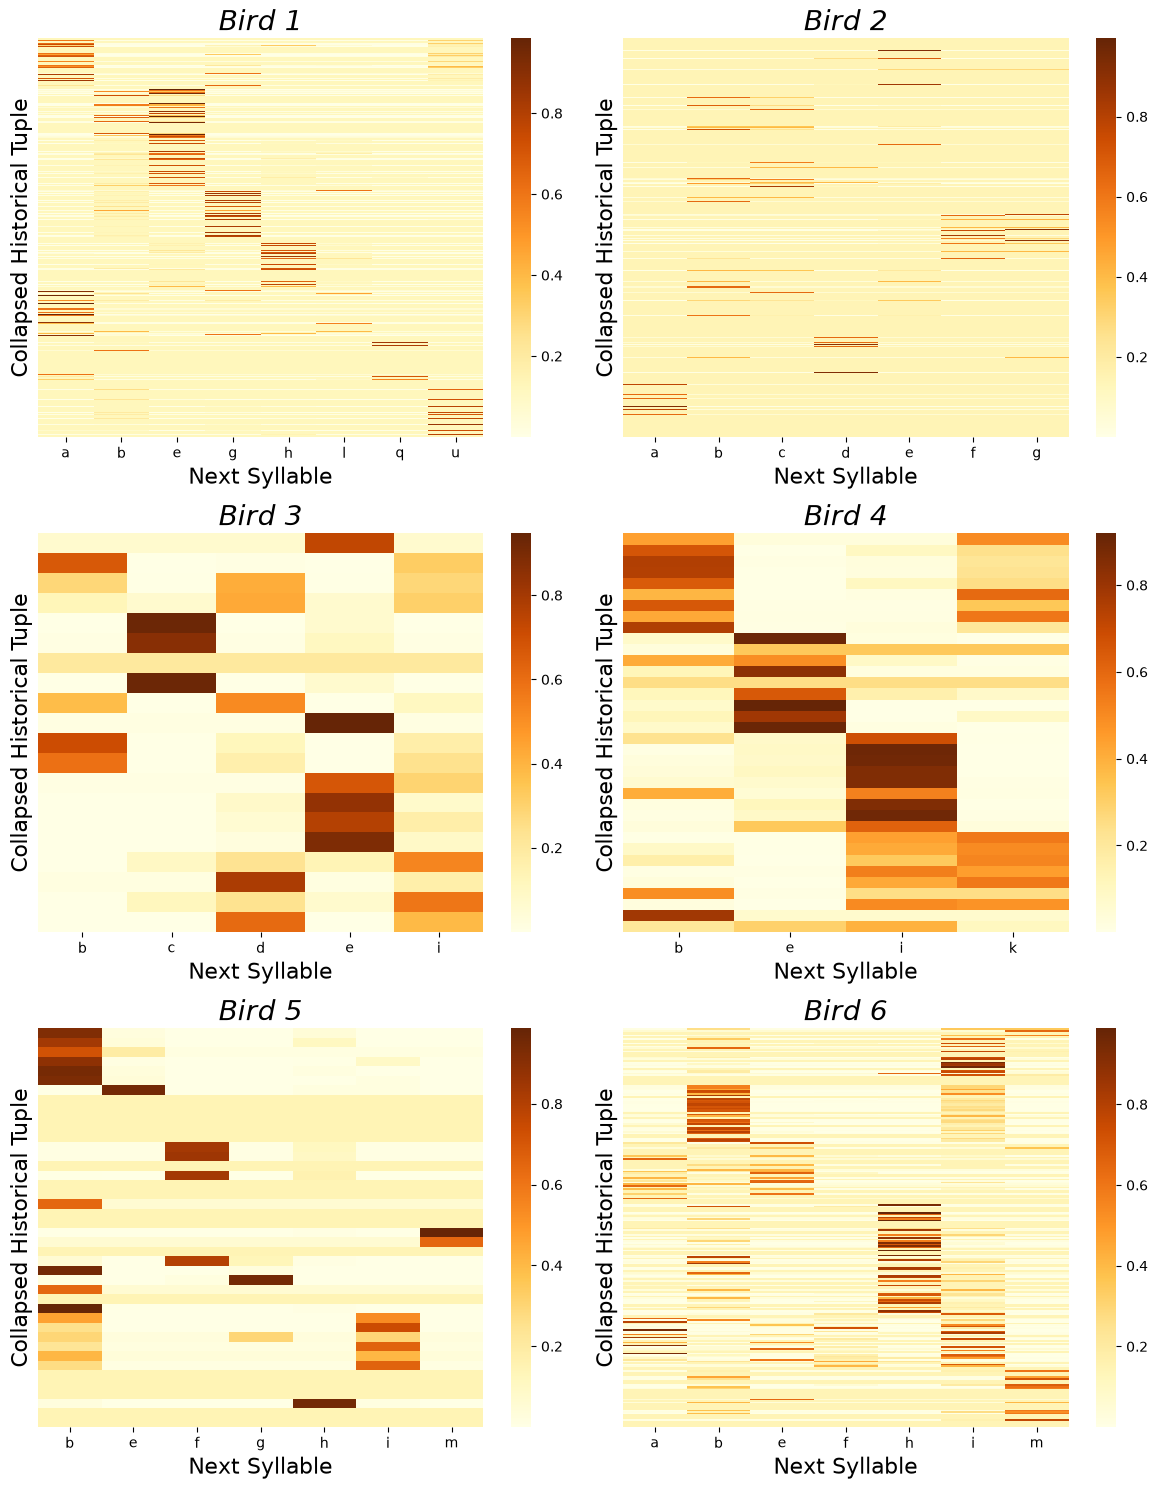

In [84]:
# BIRDS #

# user input -------

birdMap = {'bird1': [3, .1, 49, 113, "Bird 1"], 'bird2': [4, .1, 18, 47, "Bird 2"], 'bird3': [2, .1, 21, 58, "Bird 3"], 
           'bird4': [3, .1, 0, 69, "Bird 4"], 'bird5': [2, .1, 0, 41, "Bird 5"], 'bird6': [3, .1, 50, 129, "Bird 6"]}
# dict for bird: [best k, best smoother, length q1, length q3, heatmap title], 
# extracted from 05-postprocessing results (k, smoother) and 01-preprocessing statsTable (q1, q3)

nLines = 200

# run generation --------------

birds = ["bird1", "bird2", "bird3", "bird4", "bird5", "bird6"]

prefixes = pd.read_csv("../bird-data/prefixes.csv")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for loc, bird in enumerate(birds):

    ax = axes[loc]

    filename = f"../bird-data/raw/{bird}_cropped_full.txt" 

    with open(filename) as f:
        lines = f.read().splitlines() 

    lines = [x for x in lines if x]

    # find average sequence length (for generation length)
    # avgLen = round(sum(len(line) for line in lines) / len(lines))

    # set up length distribution to draw from truncated normal distribution between q1 and q3 of each corpus
    q1 = birdMap[bird][2]
    q3 = birdMap[bird][3]

    mu = (q1 + q3) / 2
    sigma = (q3 - q1) / (2 * 0.67448975)

    #beginning and end of truncated normal are not simply q1 and q3, but mean-centered and renormalized versions (see scipy.stats documentation)
    a, b = (q1 - mu)/sigma, (q3 - mu)/sigma 

    # find unique states
    states = sorted({char for line in lines for char in line})

    # k-order model
    trans = collapsedTransNorm(states = states, lines = lines, k = birdMap[bird][0], smoother = birdMap[bird][1]) 

    # k-order counts
    counts = collapsedTransCount(lines, birdMap[bird][0])

    outFilename = f"{bird}_playback.txt"

    # #write generated sequences
    with open(outFilename, "w") as f:

        for i in range(nLines):

            prefix = random.choice(
                prefixes.loc[prefixes["bird"] == bird, "fullPrefix"].tolist()
            )
            
            seqLen = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=1) #sample sequence length from truncated N dist

            generated = generate_sequence(trans, counts, birdMap[bird][0], seqLen)

            out = prefix + generated

            f.write(out + "\n")

    #plot heatmap
    pMatrix = pd.DataFrame(trans).T.fillna(0)

    sorted_index = sorted(pMatrix.index, key=lambda x: x[-1]) #sort matrix rows by most recent character in history
    pMatrix = pMatrix.reindex(sorted_index)
    
    sb.heatmap(pMatrix, yticklabels=False, xticklabels=True, cmap = "YlOrBr", ax = ax)
    ax.set_xlabel("Next Syllable", fontsize = 16)
    ax.set_ylabel("Collapsed Historical Tuple", fontsize = 16)
    ax.set_title(birdMap[bird][4], fontsize = 20, style = 'italic')

plt.tight_layout()
plt.savefig(f"../plots/birdHeatmap.png")
plt.show()
plt.close()

    
